In [67]:
import yfinance as yf
import pandas as pd
import requests

def fetch_data(ticker, start_date=None, end_date=None, interval='1d'):
    """
    Fetches OHCLV stock data and drops missing values
    """
    # Fetch the data
    stock = yf.Ticker(ticker)
    ohlcv_df = stock.history(start=start_date, end=end_date, interval=interval)

    # Remove rows with any missing values
    ohlcv_df_clean = ohlcv_df.dropna()

    # Uncomment below to print the data
    #print(stock.financials)
    #print(stock.balance_sheet)
    #print(stock.cashflow)
    return ohlcv_df_clean

#JPM JNJ PG XOM
#fetch_data(ticker, start_time, end_time)
yf_data = fetch_data("TSLA", "2025-02-07", "2025-03-06")
3

# The code below requires an API Key which can be generated from the url below. I believe the api allows
# like 1000 requests per month
def fetch_news_articles(ticker,from_date=None, to_date=None, language='en', page_size=100):

    url = 'https://newsapi.org/v2/everything'
    params = {
        'q': ticker,
        'apiKey':"298089a9705e4d05b14894434eb17c25",
        'language': language,
        'pageSize': page_size,
        'from': from_date,
        'to': to_date,
        'sortBy': 'relevancy'
    }

    response = requests.get(url, params=params)

    data = response.json()

    if data.get('status') == 'ok':
        articles = data.get('articles', [])
        news_df = pd.DataFrame(articles)[['publishedAt', 'title', 'description', 'url', 'content']]
        news_df['publishedAt'] = pd.to_datetime(news_df['publishedAt'])
        return news_df
    else:
        raise Exception(f"Error fetching news: {data.get('message', 'Unknown error')}")

# Only works up to a month back, currently only returns the title and description of articles in a pd
# dataframe. Will probably be updated soon
news_data = fetch_news_articles("TSLA", "2025-02-07", "2025-03-06")

In [68]:
yf_df = pd.DataFrame(yf_data)
yf_df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-02-07 00:00:00-05:00,370.190002,380.549988,360.339996,361.619995,70298300,0.0,0.0
2025-02-10 00:00:00-05:00,356.209991,362.700012,350.510010,350.730011,77514900,0.0,0.0
2025-02-11 00:00:00-05:00,345.799988,349.369995,325.100006,328.500000,118543400,0.0,0.0
2025-02-12 00:00:00-05:00,329.940002,346.399994,329.119995,336.510010,105382700,0.0,0.0
2025-02-13 00:00:00-05:00,345.000000,358.690002,342.850006,355.940002,89441500,0.0,0.0


In [69]:
news_df = pd.DataFrame(news_data)
news_df.head()

,publishedAt,title,description,url,content
0,2025-02-14 22:26:00+00:00,Third Point boosts its stake in these ‘Magnifi...,Daniel Loeb’s Third Point hedge fund sold off ...,https://www.marketwatch.com/story/third-point-...,Daniel Loebs Third Point hedge fund sold off i...
1,2025-03-06 09:50:00+00:00,This analyst says Tesla deliveries will be 16%...,Baird analysts are concerned that Wall Street ...,https://www.marketwatch.com/story/this-analyst...,Brace for disappointment when Tesla rolls out ...
2,2025-03-04 14:49:00+00:00,Why markets are missing risks of a Trump gover...,The “DOGE” blitz on the federal bureaucracy co...,https://www.marketwatch.com/story/why-markets-...,As Washington hurtles toward another governmen...
3,2025-02-14 16:13:25+00:00,"Uber wants Tesla's robotaxis on its app, becau...",Uber (UBER) CEO Dara Khosrowshahi would rather...,https://qz.com/uber-tesla-elon-musk-robotaxi-1...,In This Story\r\nUber (UBER-1.05%\r\n) CEO Dar...
4,2025-02-26 19:56:34+00:00,"Tesla, GM, and other car makers are winning th...",General Motors (GM) and Tesla (TSLA) have some...,https://qz.com/gm-tesla-lincoln-ford-brand-loy...,In This Story\r\nGeneral Motors (GM+3.78%\r\n)...


In [70]:
import datetime as dt

import pandas as pd
import datetime as dt

# Convert 'publishedAt' in news_df to datetime and remove timezone info
news_df['publishedAt'] = pd.to_datetime(news_df['publishedAt']).dt.tz_localize(None)
news_df['publishedAt'] = news_df['publishedAt'].dt.date

# Convert index of yf_df to 'Date' column and remove timezone info
yf_df['Date'] = yf_df.index
yf_df['Date'] = pd.to_datetime(yf_df['Date']).dt.tz_localize(None).dt.date

# Rename date
yf_df.rename(columns={'Date': 'date'}, inplace=True)

# Merge the two dataframes on the appropriate columns
merged_df = pd.merge(yf_df, news_df, left_on='date', right_on='publishedAt', how='inner')

# Drop 'publishedAt' column after merge
merged_df.drop(columns='publishedAt', inplace=True)

# Display the first few rows of the merged dataframe
merged_df.head()


,Open,High,Low,Close,Volume,Dividends,Stock Splits,date,title,description,url,content
0,370.190002,380.549988,360.339996,361.619995,70298300,0.0,0.0,2025-02-07,"The 'Magnificent Seven' era is ending, says th...",The man who coined the term “Magnificent Seven...,https://qz.com/magnificent-seven-bank-of-ameri...,In This Story\r\nThe man who coined the term M...
1,370.190002,380.549988,360.339996,361.619995,70298300,0.0,0.0,2025-02-07,"Tesla, Inc. (TSLA): Among Cathie Wood’s Top St...",None,https://consent.yahoo.com/v2/collectConsent?se...,"If you click 'Accept all', we and our partners..."
2,370.190002,380.549988,360.339996,361.619995,70298300,0.0,0.0,2025-02-07,Elon Musk's Brother Unloads Tesla Stock At A K...,"Tesla Chief Executive Elon Musk's brother, Kim...",https://www.investors.com/news/tesla-stock-elo...,Information in Investors Business Daily is for...
3,370.190002,380.549988,360.339996,361.619995,70298300,0.0,0.0,2025-02-07,The GraniteShares YieldBoost TSLA ETF (TSYY) Y...,"Since its inception on December 17, 2024, and ...",https://www.globenewswire.com/news-release/202...,"NEW YORK, Feb. 07, 2025 (GLOBE NEWSWIRE) -- Yi..."
4,356.209991,362.700012,350.510010,350.730011,77514900,0.0,0.0,2025-02-10,The next big robotaxi push is nearly here,Most Americans aren’t sold on driverless cars ...,https://qz.com/robotaxi-tesla-uber-lyft-waymo-...,In This Story\r\nMost Americans arent sold on ...


In [71]:
# Check for missing values

merged_df.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0
Dividends,0
Stock Splits,0
date,0
title,0
description,5


In [72]:
# Renaming columns

merged_df.drop(columns=['url'], inplace=True)
merged_df = merged_df[['date', 'Open', 'High', 'Low', 'Close', 'Volume', 'title', 'description', 'content']]
merged_df.rename(columns={
    'Open': 'open',
    'High': 'high',
    'Low': 'low',
    'Close': 'close',
    'Volume': 'volume'
}, inplace=True)

In [73]:
merged_df.head()

,date,open,high,low,close,volume,title,description,content
0,2025-02-07,370.190002,380.549988,360.339996,361.619995,70298300,"The 'Magnificent Seven' era is ending, says th...",The man who coined the term “Magnificent Seven...,In This Story\r\nThe man who coined the term M...
1,2025-02-07,370.190002,380.549988,360.339996,361.619995,70298300,"Tesla, Inc. (TSLA): Among Cathie Wood’s Top St...",None,"If you click 'Accept all', we and our partners..."
2,2025-02-07,370.190002,380.549988,360.339996,361.619995,70298300,Elon Musk's Brother Unloads Tesla Stock At A K...,"Tesla Chief Executive Elon Musk's brother, Kim...",Information in Investors Business Daily is for...
3,2025-02-07,370.190002,380.549988,360.339996,361.619995,70298300,The GraniteShares YieldBoost TSLA ETF (TSYY) Y...,"Since its inception on December 17, 2024, and ...","NEW YORK, Feb. 07, 2025 (GLOBE NEWSWIRE) -- Yi..."
4,2025-02-10,356.209991,362.700012,350.510010,350.730011,77514900,The next big robotaxi push is nearly here,Most Americans aren’t sold on driverless cars ...,In This Story\r\nMost Americans arent sold on ...


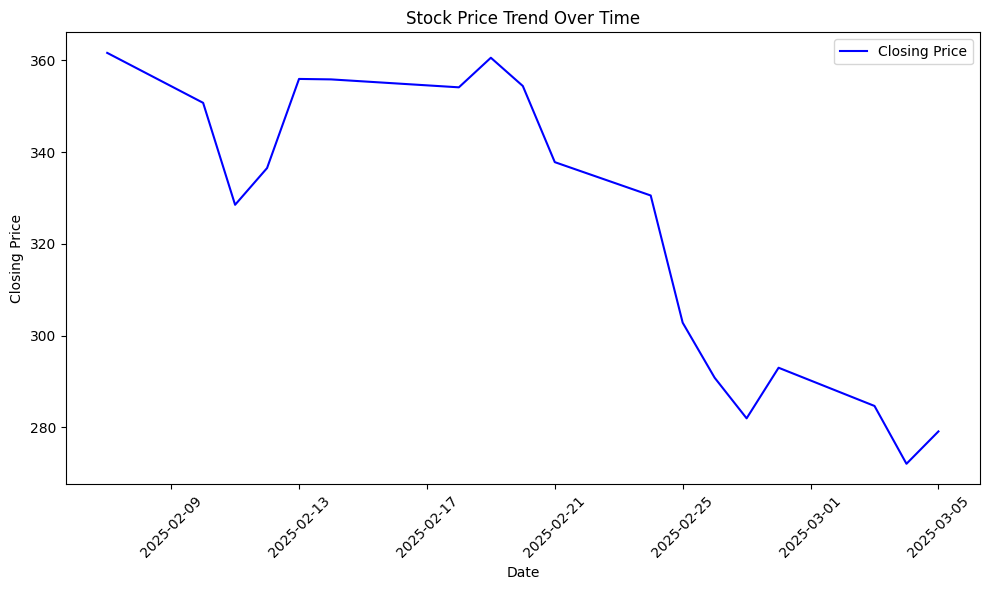

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Stock Price Trend (Close Price over Time)
plt.figure(figsize=(10, 6))
plt.plot(merged_df['date'], merged_df['close'], label='Closing Price', color='blue')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Stock Price Trend Over Time')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [75]:
#import nltk
#from nltk.sentiment.vader import SentimentIntensityAnalyzer
#from nltk.tokenize import word_tokenize
#from nltk.corpus import stopwords

#nltk.download('vader_lexicon')
#analyzer = SentimentIntensityAnalyzer()

#def get_sentiment(text):
#    sentiment = analyzer.polarity_scores(text)
#    return sentiment['compound']

#merged_df['sentiment'] = merged_df['content'].apply(get_sentiment)


In [76]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import string

nltk.download('vader_lexicon')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

analyzer = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Tokenize text
    tokens = word_tokenize(text)
    # Remove stopwords and punctuation, then apply stemming and lemmatization
    filtered_tokens = [lemmatizer.lemmatize(stemmer.stem(word.lower())) for word in tokens
                       if word.lower() not in stop_words and word not in string.punctuation]
    return ' '.join(filtered_tokens)

def get_sentiment(text):
    processed_text = preprocess_text(text)
    sentiment = analyzer.polarity_scores(processed_text)
    return sentiment['compound']

merged_df['sentiment'] = merged_df['content'].apply(get_sentiment)

merged_df.head()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,date,open,high,low,close,volume,title,description,content,sentiment
0,2025-02-07,370.190002,380.549988,360.339996,361.619995,70298300,"The 'Magnificent Seven' era is ending, says th...",The man who coined the term “Magnificent Seven...,In This Story\r\nThe man who coined the term M...,0.6124
1,2025-02-07,370.190002,380.549988,360.339996,361.619995,70298300,"Tesla, Inc. (TSLA): Among Cathie Wood’s Top St...",None,"If you click 'Accept all', we and our partners...",0.5423
2,2025-02-07,370.190002,380.549988,360.339996,361.619995,70298300,Elon Musk's Brother Unloads Tesla Stock At A K...,"Tesla Chief Executive Elon Musk's brother, Kim...",Information in Investors Business Daily is for...,0.3612
3,2025-02-07,370.190002,380.549988,360.339996,361.619995,70298300,The GraniteShares YieldBoost TSLA ETF (TSYY) Y...,"Since its inception on December 17, 2024, and ...","NEW YORK, Feb. 07, 2025 (GLOBE NEWSWIRE) -- Yi...",0.0000
4,2025-02-10,356.209991,362.700012,350.510010,350.730011,77514900,The next big robotaxi push is nearly here,Most Americans aren’t sold on driverless cars ...,In This Story\r\nMost Americans arent sold on ...,0.0000


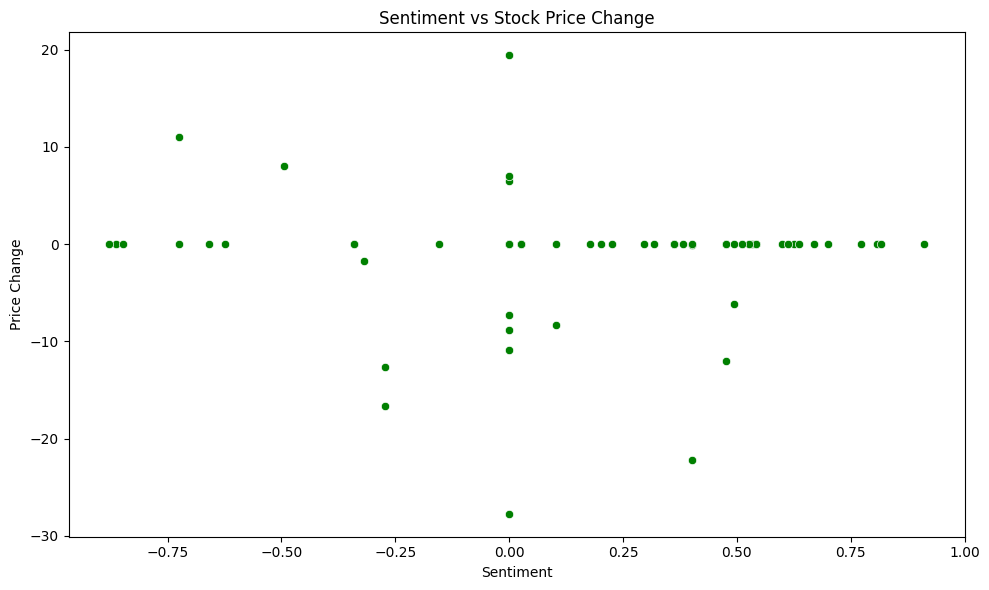

In [77]:
merged_df['price_change'] = merged_df['close'].diff()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=merged_df['sentiment'], y=merged_df['price_change'], color='green')
plt.xlabel('Sentiment')
plt.ylabel('Price Change')
plt.title('Sentiment vs Stock Price Change')
plt.tight_layout()
plt.show()